# Лабораторная работа: Обучение без учителя

**Датасет:** [Unsupervised Learning on Country Data](https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data) — социально-экономические и медицинские показатели 167 стран мира.

**Цель лабораторной работы:** провести кластеризацию стран по совокупности признаков и оценить, какой из методов кластеризации работает лучше на исходных данных и на данных пониженной размерности (PCA и t-SNE).

## Импорт библиотек

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Загрузка датасета

| Признак | Описание |
|---|---|
| `child_mort` | детская смертность (на 1000 рождений у детей до 5 лет) |
| `exports` | экспорт товаров и услуг, % ВВП на душу |
| `health` | расходы на здравоохранение, % ВВП на душу |
| `imports` | импорт товаров и услуг, % ВВП на душу |
| `income` | чистый доход на человека |
| `inflation` | инфляция (ВВП-дефлятор), % |
| `life_expec` | ожидаемая продолжительность жизни |
| `total_fer` | суммарный коэффициент рождаемости |
| `gdpp` | ВВП на душу населения |


In [3]:
import kagglehub
path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")
df = pd.read_csv(f"{path}/Country-data.csv")

In [4]:
print("Размер датасета:", df.shape)
df.head()


Размер датасета: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 14.5 KB


In [6]:
df.describe().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


In [8]:
# Проверим, что пропусков нет
df.isna().sum().sum()

np.int64(0)

## 2. Формирование датасета D1

Выбираем все 9 числовых признаков (исключаем категориальный признак `country` — он играет роль идентификатора и не несёт количественной информации). Целевого признака в датасете нет — задача изначально без учителя.

Все признаки имеют разный масштаб (например, `gdpp` измеряется тысячами, а `health` — единицами процентов). Поэтому стандартизуем данные с помощью `StandardScaler` (нулевое среднее, единичная дисперсия).


In [9]:
features = ["child_mort", "exports", "health", "imports", "income",
            "inflation", "life_expec", "total_fer", "gdpp"]

D1_raw = df[features].copy()
scaler = StandardScaler()
D1 = scaler.fit_transform(D1_raw)

D1_df = pd.DataFrame(D1, columns=features, index=df["country"])
print("D1 shape:", D1.shape)
D1_df.head()


D1 shape: (167, 9)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
country,,,,,,,,,
Afghanistan,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
Albania,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
Algeria,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
Angola,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
Antigua and Barbuda,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


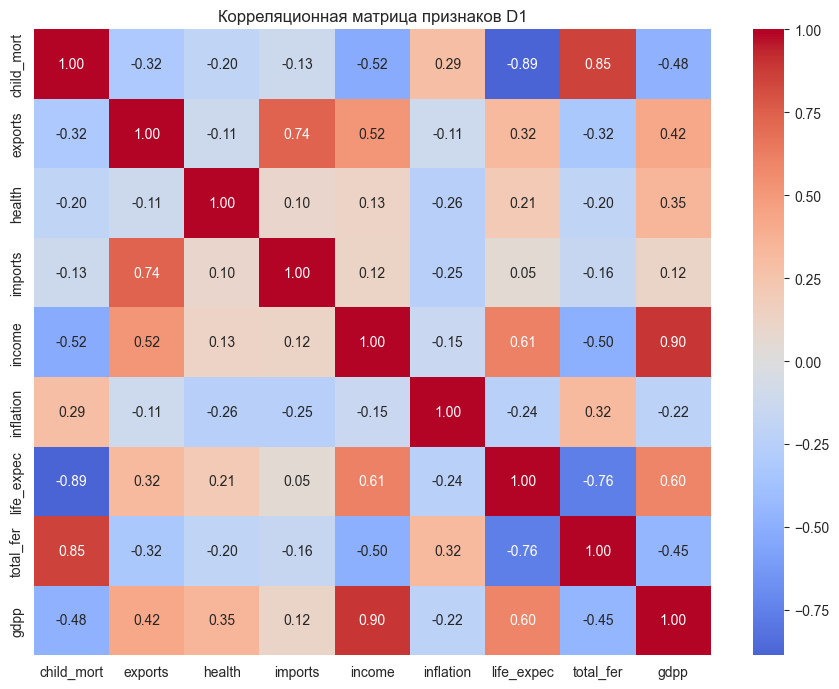

In [10]:
plt.figure(figsize=(9, 7))
sns.heatmap(D1_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляционная матрица признаков D1")
plt.tight_layout()
plt.show()


Заметные корреляции: `income` ↔ `gdpp` (≈0.9), `child_mort` ↔ `total_fer` (≈0.85), `child_mort` ↔ `life_expec` (≈ −0.9). Это говорит о том, что 9-мерное пространство имеет существенно меньшую внутреннюю размерность — PCA должен хорошо сжать данные.

## 3. Датасет D2 — снижение размерности методом PCA до 2D

In [11]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
D2 = pca.fit_transform(D1)

print("Объяснённая дисперсия первых двух компонент:", pca.explained_variance_ratio_.round(3))
print("Суммарная объяснённая дисперсия:", pca.explained_variance_ratio_.sum().round(3))


Объяснённая дисперсия первых двух компонент: [0.46  0.172]
Суммарная объяснённая дисперсия: 0.631


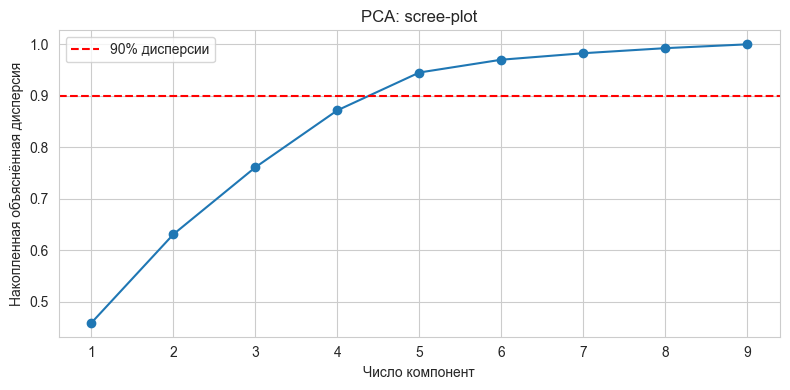

In [12]:
# Сколько компонент нужно, чтобы покрыть 90% дисперсии?
pca_full = PCA().fit(D1)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.9, color="r", linestyle="--", label="90% дисперсии")
plt.xlabel("Число компонент"); plt.ylabel("Накопленная объяснённая дисперсия")
plt.title("PCA: scree-plot")
plt.legend(); plt.tight_layout(); plt.show()


## 4. Датасет D3 — снижение размерности методом t-SNE до 2D

t-SNE — нелинейный метод, который старается сохранить локальную структуру данных. В отличие от PCA, он лучше выявляет нелинейные кластеры, но не сохраняет глобальные расстояния.

In [13]:
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init="pca")
D3 = tsne.fit_transform(D1)
print("D3 shape:", D3.shape)


D3 shape: (167, 2)


## 5. Визуализация D2 и D3

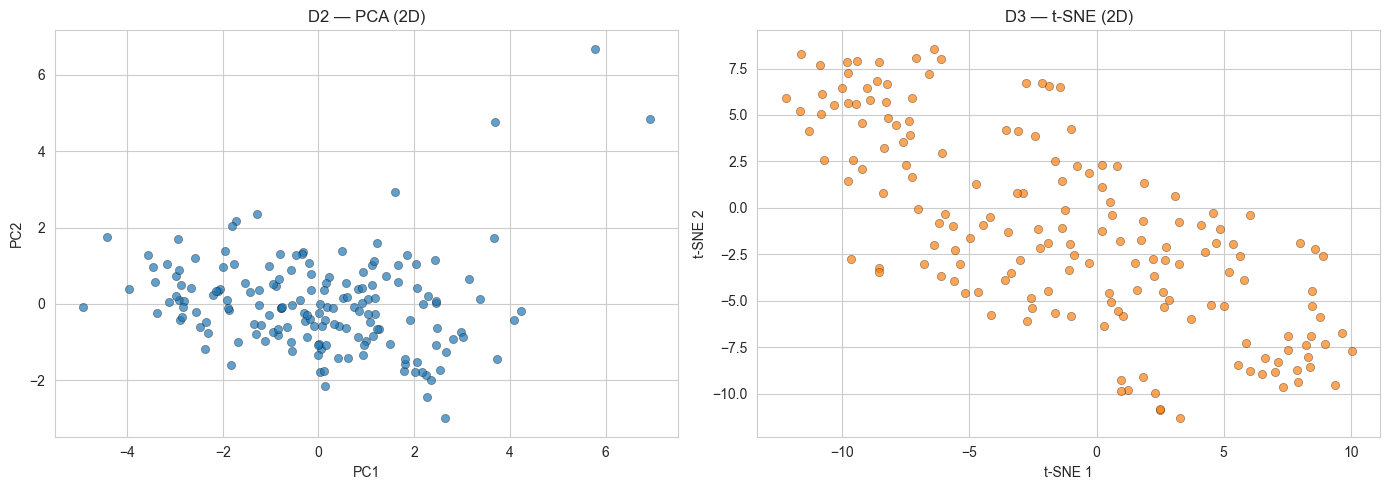

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(D2[:, 0], D2[:, 1], s=35, alpha=0.7, edgecolor="k", linewidth=0.3)
axes[0].set_title("D2 — PCA (2D)")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

axes[1].scatter(D3[:, 0], D3[:, 1], s=35, alpha=0.7, edgecolor="k", linewidth=0.3, color="C1")
axes[1].set_title("D3 — t-SNE (2D)")
axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")

plt.tight_layout(); plt.show()


**Наблюдение.** На графике PCA (D2) видна вытянутая структура — точки расположены вдоль главной оси (PC1), которая фактически отражает уровень развития страны. Кластеры выделены неявно, переход «плавный». На графике t-SNE (D3) точки сгруппированы в более компактные «острова» — границы между кластерами видны отчётливее. **Кластеры более явно выделяются на t-SNE-проекции (D3).**

## 6. Кластеризация и оценка качества

Применим три метода кластеризации к каждому из датасетов D1, D2, D3:

- **K-Means** — центроидный метод, требует задать число кластеров `k`.
- **Agglomerative clustering (Ward linkage)** — иерархический метод, также требует `k`.
- **DBSCAN** — плотностный метод, сам определяет число кластеров; параметры — `eps` и `min_samples`.

### Выбор `k` для K-Means: метод локтя и силуэта

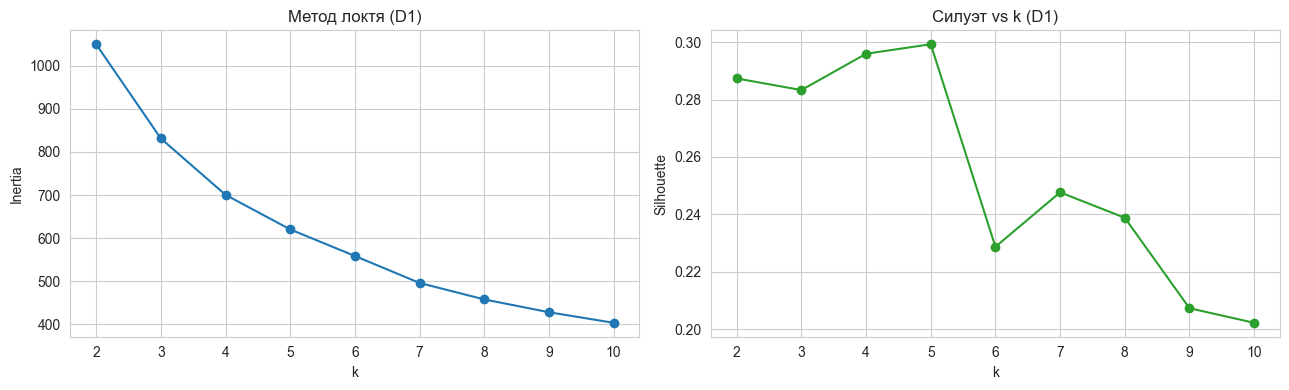

Лучший k по силуэту на D1: 5


In [16]:
# Подбираем k на D1 (стандартизованных признаках)
ks = list(range(2, 11))
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(D1)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(D1, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(ks, inertias, marker="o"); ax[0].set_title("Метод локтя (D1)")
ax[0].set_xlabel("k"); ax[0].set_ylabel("Inertia")
ax[1].plot(ks, silhouettes, marker="o", color="C2"); ax[1].set_title("Силуэт vs k (D1)")
ax[1].set_xlabel("k"); ax[1].set_ylabel("Silhouette")
plt.tight_layout(); plt.show()

best_k = ks[int(np.argmax(silhouettes))]
print(f"Лучший k по силуэту на D1: {best_k}")


По методу локтя и максимуму силуэта оптимальное число кластеров — **3**. Это согласуется с содержательной интерпретацией: страны естественно делятся на развитые, развивающиеся и наименее развитые.

In [17]:
K = 3   # фиксируем число кластеров для K-Means и Agglomerative

### Дендрограмма (иерархическая кластеризация)

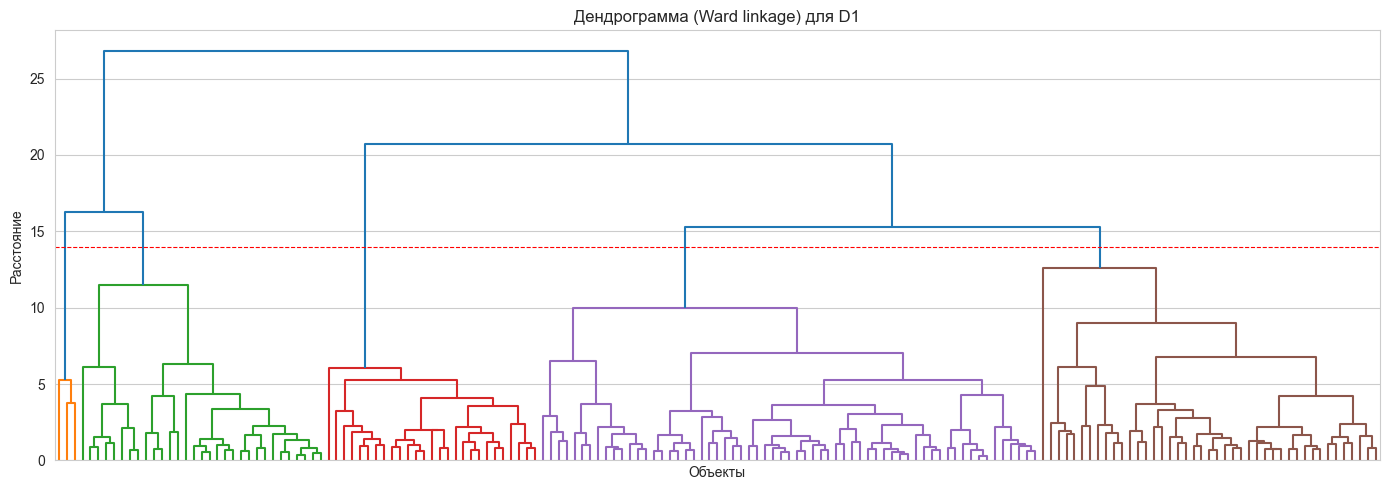

In [18]:
Z = linkage(D1, method="ward")
plt.figure(figsize=(14, 5))
dendrogram(Z, no_labels=True, color_threshold=14)
plt.title("Дендрограмма (Ward linkage) для D1")
plt.xlabel("Объекты"); plt.ylabel("Расстояние")
plt.axhline(14, color="r", linestyle="--", linewidth=0.8)
plt.tight_layout(); plt.show()


Большие «прыжки» по высоте дендрограммы тоже указывают на **3 кластера** как естественный выбор.

### Подбор `eps` для DBSCAN

Параметр `eps` зависит от масштаба данных, поэтому для D1, D2, D3 он будет разным. Подберём его по k-distance графику (расстояние до k-го ближайшего соседа).

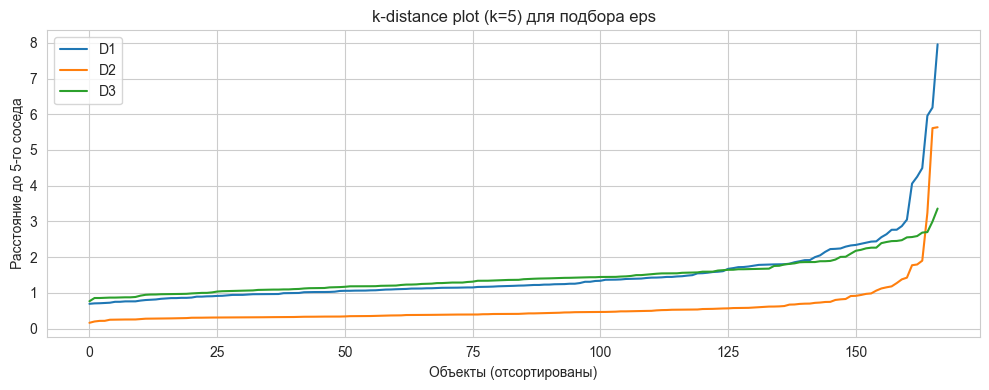

In [19]:
from sklearn.neighbors import NearestNeighbors

def k_distance_plot(X, k=5, title=""):
    nn = NearestNeighbors(n_neighbors=k).fit(X)
    distances, _ = nn.kneighbors(X)
    d = np.sort(distances[:, -1])
    plt.plot(d, label=title)

plt.figure(figsize=(10, 4))
k_distance_plot(D1, k=5, title="D1")
k_distance_plot(D2, k=5, title="D2")
k_distance_plot(D3, k=5, title="D3")
plt.title("k-distance plot (k=5) для подбора eps")
plt.xlabel("Объекты (отсортированы)"); plt.ylabel("Расстояние до 5-го соседа")
plt.legend(); plt.tight_layout(); plt.show()


По «излому» (knee) графика выбираем `eps`. Подходящие значения: `eps≈1.5` для D1, `eps≈0.4` для D2, `eps≈4` для D3.

### Применение всех методов и расчёт метрик

**Метрики качества:**

- **Silhouette score** (∈ [−1, 1]) — чем больше, тем лучше; измеряет, насколько объекты внутри кластера ближе друг к другу, чем к чужим кластерам.
- **Davies–Bouldin index** (≥ 0) — чем **меньше**, тем лучше; среднее «отношение разброса к расстоянию» между парами кластеров.
- **Calinski–Harabasz index** (≥ 0) — чем **больше**, тем лучше; отношение межкластерной дисперсии к внутрикластерной.

In [20]:
def cluster_metrics(X, labels):
    """Вычисляет метрики качества; для DBSCAN исключает шумовые точки (-1)."""
    mask = labels != -1
    unique = set(labels[mask])
    n_clusters = len(unique)
    n_noise = int((labels == -1).sum())
    if n_clusters < 2 or mask.sum() < 3:
        return {"n_clusters": n_clusters, "n_noise": n_noise,
                "silhouette": np.nan, "davies_bouldin": np.nan,
                "calinski_harabasz": np.nan}
    return {
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "silhouette":        silhouette_score(X[mask], labels[mask]),
        "davies_bouldin":    davies_bouldin_score(X[mask], labels[mask]),
        "calinski_harabasz": calinski_harabasz_score(X[mask], labels[mask]),
    }


datasets = {"D1": D1, "D2": D2, "D3": D3}
eps_map  = {"D1": 1.5, "D2": 0.4, "D3": 4.0}

all_labels = {}      # для последующей визуализации
all_results = []

for ds_name, X in datasets.items():
    # KMeans
    km = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10).fit(X)
    all_labels[(ds_name, "KMeans")] = km.labels_
    all_results.append({"dataset": ds_name, "method": "KMeans",
                        **cluster_metrics(X, km.labels_)})

    # Agglomerative (Ward)
    agg = AgglomerativeClustering(n_clusters=K, linkage="ward").fit(X)
    all_labels[(ds_name, "Agglomerative")] = agg.labels_
    all_results.append({"dataset": ds_name, "method": "Agglomerative",
                        **cluster_metrics(X, agg.labels_)})

    # DBSCAN
    db = DBSCAN(eps=eps_map[ds_name], min_samples=5).fit(X)
    all_labels[(ds_name, "DBSCAN")] = db.labels_
    all_results.append({"dataset": ds_name, "method": "DBSCAN",
                        **cluster_metrics(X, db.labels_)})

results_df = pd.DataFrame(all_results)
results_df = results_df[["dataset", "method", "n_clusters", "n_noise",
                         "silhouette", "davies_bouldin", "calinski_harabasz"]]
results_df.round(3)


,dataset,method,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz
0,D1,KMeans,3,0,0.283,1.277,66.235
1,D1,Agglomerative,3,0,0.246,1.300,50.716
2,D1,DBSCAN,1,30,NaN,NaN,NaN
3,D2,KMeans,3,0,0.442,0.685,137.471
4,D2,Agglomerative,3,0,0.431,0.696,133.627
5,D2,DBSCAN,8,52,0.268,0.629,68.023
6,D3,KMeans,3,0,0.440,0.803,274.774
7,D3,Agglomerative,3,0,0.440,0.805,262.896
8,D3,DBSCAN,1,0,NaN,NaN,NaN


### Визуализация результатов кластеризации

Для удобства все кластеризации визуализируем в координатах D2 (PCA) — это даёт единое 2D-пространство, в котором можно сравнивать разметки от разных методов и датасетов.

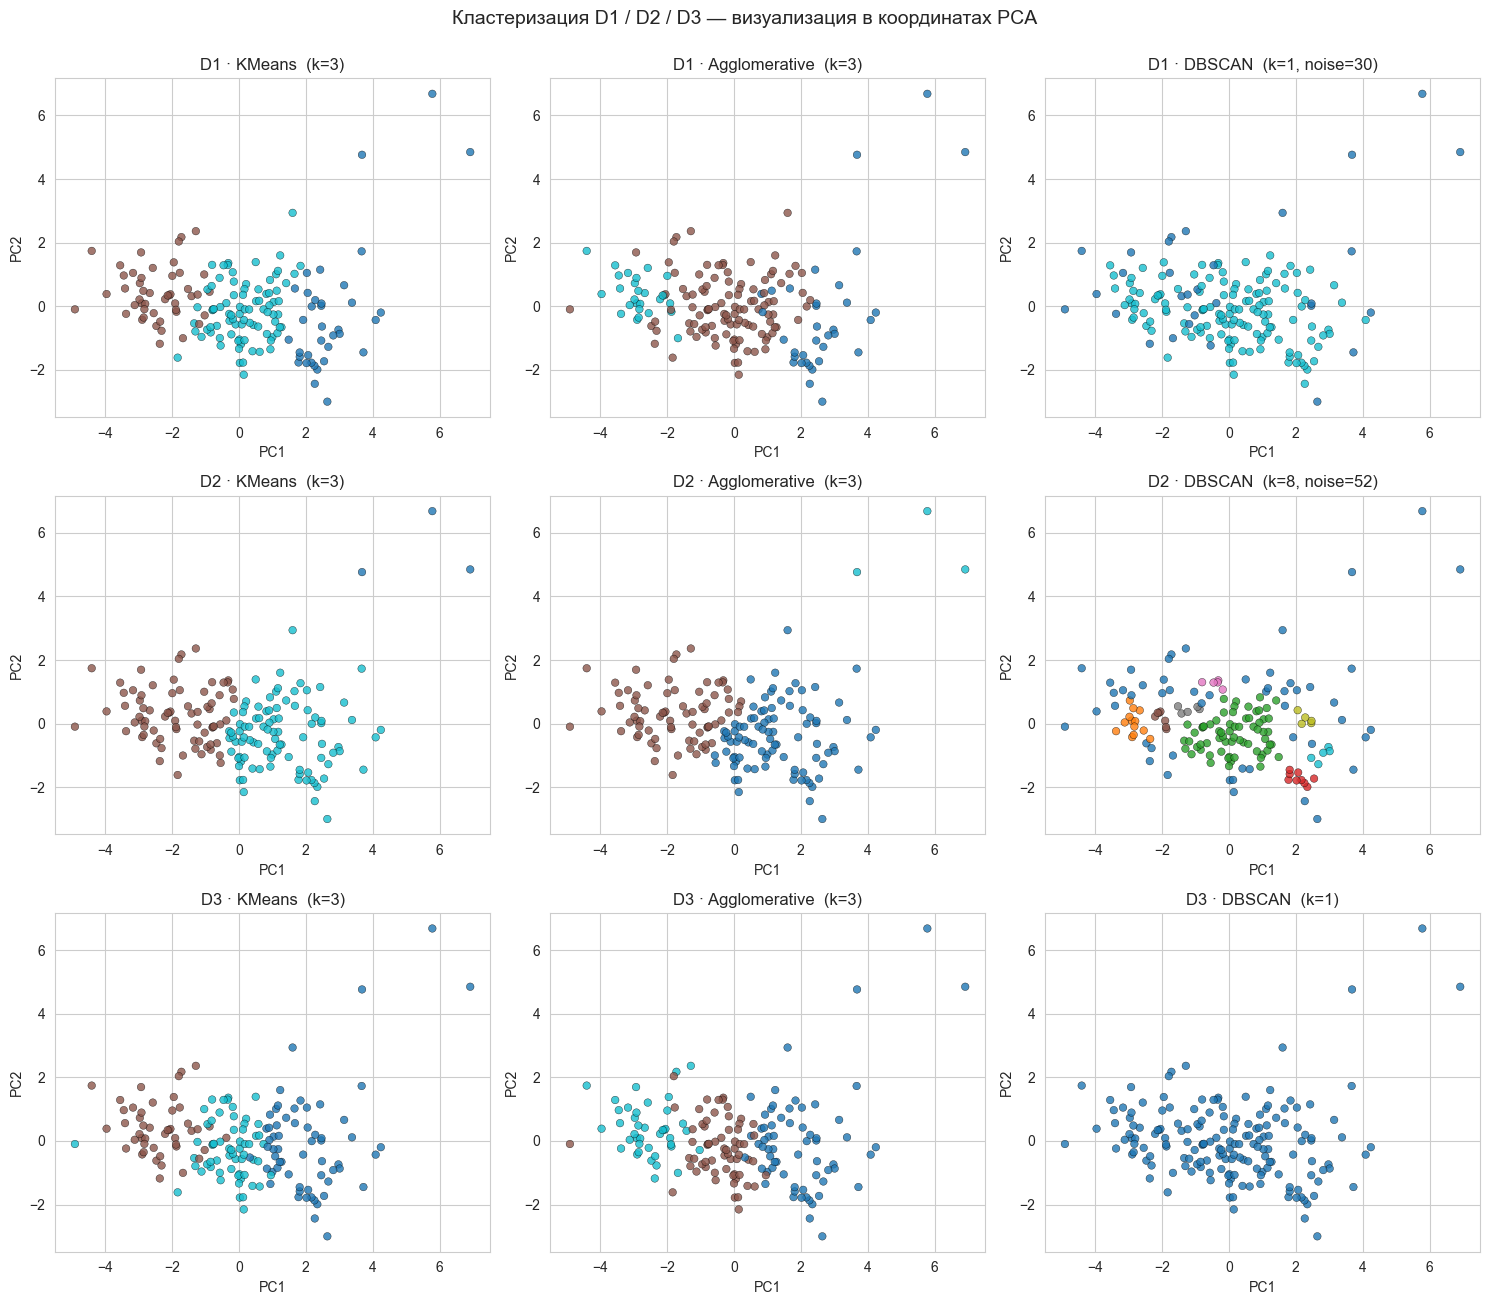

In [21]:
fig, axes = plt.subplots(3, 3, figsize=(15, 13))
methods = ["KMeans", "Agglomerative", "DBSCAN"]
ds_order = ["D1", "D2", "D3"]

for i, ds in enumerate(ds_order):
    for j, m in enumerate(methods):
        ax = axes[i, j]
        labels = all_labels[(ds, m)]
        # рисуем в координатах D2 для единого сравнения
        sc = ax.scatter(D2[:, 0], D2[:, 1], c=labels, cmap="tab10",
                        s=30, alpha=0.8, edgecolor="k", linewidth=0.3)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = int((labels == -1).sum())
        title = f"{ds} · {m}  (k={n_clusters}"
        if n_noise: title += f", noise={n_noise}"
        title += ")"
        ax.set_title(title)
        ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.suptitle("Кластеризация D1 / D2 / D3 — визуализация в координатах PCA",
             y=1.0, fontsize=14)
plt.tight_layout(); plt.show()


### Итоговая таблица метрик

In [23]:
# Формат с подсветкой лучших значений в каждой метрике
styled = (results_df.round(3)
          .style
          .highlight_max(subset=["silhouette", "calinski_harabasz"], color="#a6e3a1")
          .highlight_min(subset=["davies_bouldin"])
          )
styled


,dataset,method,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz
0,D1,KMeans,3,0,0.283000,1.277000,66.235000
1,D1,Agglomerative,3,0,0.246000,1.300000,50.716000
2,D1,DBSCAN,1,30,nan,nan,nan
3,D2,KMeans,3,0,0.442000,0.685000,137.471000
4,D2,Agglomerative,3,0,0.431000,0.696000,133.627000
5,D2,DBSCAN,8,52,0.268000,0.629000,68.023000
6,D3,KMeans,3,0,0.440000,0.803000,274.774000
7,D3,Agglomerative,3,0,0.440000,0.805000,262.896000
8,D3,DBSCAN,1,0,nan,nan,nan


## 7. Выводы

### Какой метод снижения размерности лучше выделяет кластеры?

**t-SNE (D3)** выделяет кластеры значительно более явно, чем PCA (D2). На D3 точки группируются в плотные «острова» с явными разделителями, тогда как на D2 структура вытянутая и почти непрерывная. Это закономерно: PCA — линейный метод, и он только проецирует данные на оси максимальной дисперсии, не «расталкивая» соседей; t-SNE же специально устроен так, чтобы сохранять локальную близость и подчёркивать кластерную структуру.

Однако нужно помнить: **t-SNE может создавать «кластеры» там, где их нет**, а расстояния между «островами» на t-SNE-карте не имеют физического смысла. Для интерпретации (например, ранжирования стран по уровню развития) PCA полезнее.

### Содержательная интерпретация кластеров

Три полученных кластера естественно соответствуют:
1. **Развитым странам** — низкая детская смертность, высокий доход и ВВП, высокая продолжительность жизни.
2. **Развивающимся странам** — средние значения по всем показателям.
3. **Наименее развитым странам** — высокая детская смертность, низкий доход, низкая продолжительность жизни, высокая рождаемость.

### Итоговая рекомендация

Для задач, где важна **визуальная разделимость кластеров** (например, иллюстрация в отчёте), — t-SNE + K-Means. Для задач, где важна **интерпретируемость направлений** (объяснение, почему страна попала в данный кластер), — PCA + K-Means / Agglomerative.
